# Simulated Annealing Baseline — Tutor-Preference Timetabling (Small Slice)

**Scope, per thesis design:**
- Tutor-course-class assignment is **fixed input** (who teaches what is never changed).
- The optimiser only reassigns the **timeslot and room** of each already-assigned session.
- Objective: minimise total tutor preference violation (raw sum, unweighted).
  The staff-fairness metric (Jain's index / max-min fairness) is **not yet implemented**;
  this notebook establishes the plain preference-violation baseline it will later sit on top of.

**Data used** (small slice: first 12 IT tutors, ~87 sessions):
`schedule_cleaned_it.csv`, `tutors_anonymized.csv`, `profiles.csv`, `rooms_capacities.csv`, `slots.csv`


In [1]:
import csv
import random
import math
import time
from collections import defaultdict

random.seed(42)  # reproducibility


## 1. Load data

In [3]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv("/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data/schedule_cleaned_it.csv")
tutor_profile_rows = load_csv("/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data/tutors_anonymized.csv")
profile_rows = load_csv("/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data/profiles.csv")
room_rows = load_csv("/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data/rooms_capacities.csv")
slot_rows = load_csv("/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data/slots.csv")

tutor_to_profile = {r["TUTOR_ID"]: r["PROFILE_ID"] for r in tutor_profile_rows}
room_capacity = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in room_rows}
all_room_ids = list(room_capacity.keys())

# slot lookup: SLOT_ID -> (day, start_time, end_time); also reverse (day,start) -> SLOT_ID
slot_info = {r["SLOT_ID"]: (r["DAY"], r["START_TIME"], r["END_TIME"]) for r in slot_rows}
day_start_to_slot = {(r["DAY"], r["START_TIME"]): r["SLOT_ID"] for r in slot_rows}
all_slot_ids = list(slot_info.keys())

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]

def slot_sort_key(slot_id):
    day, start, _ = slot_info[slot_id]
    hh, mm = map(int, start.split(":"))
    return (DAY_ORDER.index(day), hh * 60 + mm)

slots_by_day = defaultdict(list)
for sid in all_slot_ids:
    d, _, _ = slot_info[sid]
    slots_by_day[d].append(sid)
for d in slots_by_day:
    slots_by_day[d].sort(key=slot_sort_key)

print(f"Loaded {len(schedule_rows)} IT sessions, {len(tutor_profile_rows)} tutor-profile mappings, "
      f"{len(room_rows)} rooms, {len(slot_rows)} weekly slots.")


Loaded 580 IT sessions, 431 tutor-profile mappings, 195 rooms, 35 weekly slots.


## 2. Build the small slice

First 12 IT tutors and all their sessions — small enough to run quickly as a draft baseline,
large enough to be a real, non-trivial instance.

In [4]:
all_it_tutors = sorted(set(r["TUTOR_ID"] for r in schedule_rows))
SLICE_SIZE = 12
slice_tutors = set(all_it_tutors[:SLICE_SIZE])

sessions = []
for r in schedule_rows:
    if r["TUTOR_ID"] not in slice_tutors:
        continue
    slot_id = day_start_to_slot.get((r["DAY"], r["START_TIME"]))
    if slot_id is None:
        continue  # skip anything that doesn't map cleanly onto the slot grid
    sessions.append({
        "course": r["COURSE_ID"],
        "class_id": r["CLASS_ID"],
        "tutor": r["TUTOR_ID"],
        "enrolled": int(r["ENROLLED_STUDENTS"]),
        "slot": slot_id,      # current (real) slot -> this is what SA will reassign
        "room": r["ROOM_ID"], # current (real) room -> this is what SA will reassign
    })

print(f"Slice: {len(slice_tutors)} tutors, {len(sessions)} sessions, "
      f"{len(set(s['course'] for s in sessions))} courses, "
      f"{len(set(s['class_id'] for s in sessions))} classes, "
      f"{len(set(s['room'] for s in sessions))} rooms (as scheduled).")


Slice: 12 tutors, 87 sessions, 8 courses, 39 classes, 23 rooms (as scheduled).


## 3. Preference scoring per profile

Each tutor is mapped to one of six profiles (`profiles.csv`):

| Profile | Meaning |
|---|---|
| P1 | Morning-only (before ~12:00) |
| P2 | Night owl (afternoon/evening only) |
| P3 | Compact week (fewer distinct teaching days) |
| P4 | Prefers idle time (gaps) between classes |
| P5 | Dislikes idle time (wants back-to-back classes) |
| P6 | No preference |

Profile types like "compact week" or "gaps" depend on a tutor's **whole week**, not a single
session, so scoring is computed per-tutor over all of their currently assigned slots.

In [6]:
def is_morning(slot_id):
    _, start, _ = slot_info[slot_id]
    hh = int(start.split(":")[0])
    return hh < 12

def _slots_by_day_for_tutor(tutor_slots):
    by_day = defaultdict(list)
    for s in tutor_slots:
        d, _, _ = slot_info[s]
        by_day[d].append(s)
    for d in by_day:
        by_day[d].sort(key=slot_sort_key)
    return by_day

def _adjacent_session_count(tutor_slots):
    """Count pairs of back-to-back sessions on the same day (bad for P4)."""
    count = 0
    by_day = _slots_by_day_for_tutor(tutor_slots)
    for d, slots_here in by_day.items():
        ordered_day_slots = slots_by_day[d]
        positions = sorted(ordered_day_slots.index(s) for s in slots_here)
        for i in range(len(positions) - 1):
            if positions[i + 1] - positions[i] == 1:
                count += 1
    return count

def _gap_count(tutor_slots):
    """Count idle gaps between a tutor's sessions on the same day (bad for P5)."""
    count = 0
    by_day = _slots_by_day_for_tutor(tutor_slots)
    for d, slots_here in by_day.items():
        ordered_day_slots = slots_by_day[d]
        positions = sorted(ordered_day_slots.index(s) for s in slots_here)
        for i in range(len(positions) - 1):
            gap = positions[i + 1] - positions[i] - 1
            if gap > 0:
                count += gap
    return count

def tutor_penalty(tutor_id, tutor_slots):
    """tutor_slots: list of slot_ids currently assigned to this tutor's sessions."""
    profile = tutor_to_profile[tutor_id]
    penalty = 0

    if profile == "P1":  # morning-only
        penalty += sum(1 for s in tutor_slots if not is_morning(s))
    elif profile == "P2":  # night owl
        penalty += sum(1 for s in tutor_slots if is_morning(s))
    elif profile == "P3":  # compact week: fewer distinct days is better
        days_used = len(set(slot_info[s][0] for s in tutor_slots))
        penalty += days_used
    elif profile == "P4":  # prefers idle time (gaps)
        penalty += _adjacent_session_count(tutor_slots)
    elif profile == "P5":  # dislikes idle time (wants back-to-back)
        penalty += _gap_count(tutor_slots)
    elif profile == "P6":  # no preference
        penalty += 0

    return penalty

def total_violation(sessions_state):
    """Sum of preference-violation penalties across all tutors in the slice."""
    slots_per_tutor = defaultdict(list)
    for s in sessions_state:
        slots_per_tutor[s["tutor"]].append(s["slot"])
    return sum(tutor_penalty(t, slots) for t, slots in slots_per_tutor.items())


## 4. Hard-constraint checking

In [8]:
HARD_PENALTY = 1000  # weight per hard-constraint violation

def count_hard_violations(sessions_state):
    tutor_slot_count = defaultdict(int)
    room_slot_count = defaultdict(int)
    capacity_violations = 0
    for s in sessions_state:
        tutor_slot_count[(s["tutor"], s["slot"])] += 1
        room_slot_count[(s["room"], s["slot"])] += 1
        if room_capacity[s["room"]] < s["enrolled"]:
            capacity_violations += 1
    tutor_clashes = sum(c - 1 for c in tutor_slot_count.values() if c > 1)
    room_clashes = sum(c - 1 for c in room_slot_count.values() if c > 1)
    return tutor_clashes + room_clashes + capacity_violations

def is_feasible(sessions_state):
    return count_hard_violations(sessions_state) == 0

def cost_function(sessions_state):
    """Total cost = hard-constraint penalty + raw preference violation."""
    return HARD_PENALTY * count_hard_violations(sessions_state) + total_violation(sessions_state)


## 5. Simulated annealing

In [9]:
def sa_optimise(initial_sessions, max_iterations=5000, T0=50.0, cooling=0.998):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_function(current)
    best = [dict(s) for s in current]
    best_cost = current_cost

    T = T0
    accepted = 0
    history = []

    for it in range(1, max_iterations + 1):
        idx = random.randrange(len(current))
        old_slot = current[idx]["slot"]
        old_room = current[idx]["room"]

        # propose a new (slot, room) for this one session
        new_slot = random.choice(all_slot_ids)
        new_room = random.choice(all_room_ids)

        current[idx]["slot"] = new_slot
        current[idx]["room"] = new_room

        new_cost = cost_function(current)
        delta = new_cost - current_cost

        if delta <= 0 or random.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(s) for s in current]
        else:
            current[idx]["slot"] = old_slot
            current[idx]["room"] = old_room

        history.append(current_cost)
        T *= cooling

    return best, best_cost, accepted, history


## 6. Run: baseline (current real schedule) vs. SA-optimised

In [11]:
MAX_ITER = 5000
baseline_hard = count_hard_violations(sessions)
baseline_pref = total_violation(sessions)
baseline_cost = cost_function(sessions)

print("--- BASELINE (current, un-optimized schedule) ---")
print(f"Hard-constraint violations: {baseline_hard}")
print(f"Preference-violation score: {baseline_pref}")
print(f"Combined cost (hard*{HARD_PENALTY} + preference): {baseline_cost}")


--- BASELINE (current, un-optimized schedule) ---
Hard-constraint violations: 9
Preference-violation score: 40
Combined cost (hard*1000 + preference): 9040


In [12]:
t0 = time.time()
best_sessions, best_cost, accepted, history = sa_optimise(
    sessions, max_iterations=MAX_ITER, T0=50.0, cooling=0.998
)
elapsed = time.time() - t0

best_hard = count_hard_violations(best_sessions)
best_pref = total_violation(best_sessions)

print("--- SIMULATED ANNEALING RESULT ---")
print(f"Iterations: {MAX_ITER}")
print(f"Accepted moves: {accepted}")
print(f"Runtime: {elapsed:.2f} seconds")
print(f"Hard-constraint violations: {best_hard} (was {baseline_hard})")
print(f"Preference-violation score: {best_pref} (was {baseline_pref})")
print(f"Combined cost: {best_cost} (was {baseline_cost})")
print(f"Combined-cost improvement: {baseline_cost - best_cost} "
      f"({100 * (baseline_cost - best_cost) / baseline_cost:.1f}% reduction)")
print(f"Final solution fully feasible: {is_feasible(best_sessions)}")


--- SIMULATED ANNEALING RESULT ---
Iterations: 5000
Accepted moves: 2331
Runtime: 0.38 seconds
Hard-constraint violations: 0 (was 9)
Preference-violation score: 7 (was 40)
Combined cost: 7 (was 9040)
Combined-cost improvement: 9033 (99.9% reduction)
Final solution fully feasible: True


## 7. Convergence plot

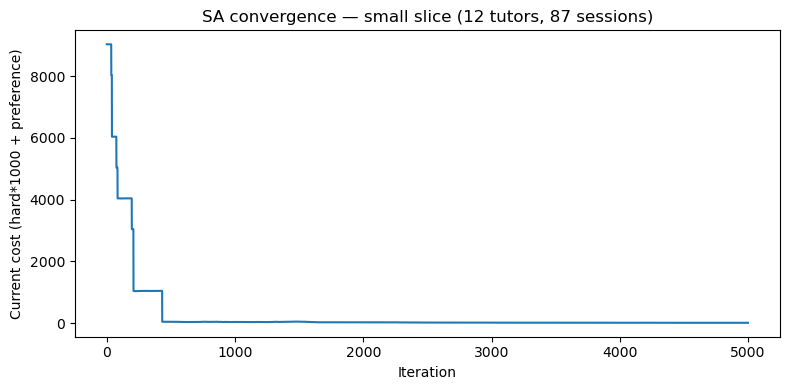

In [13]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.xlabel("Iteration")
    plt.ylabel("Current cost (hard*1000 + preference)")
    plt.title("SA convergence — small slice (12 tutors, 87 sessions)")
    plt.tight_layout()
    plt.savefig("sa_convergence.png", dpi=150)
    plt.show()
except ImportError:
    print("matplotlib not installed — skip this cell or `pip install matplotlib` to see the plot.")
